<a href="https://colab.research.google.com/github/pmolinari2910/Modelizado-de-IA/blob/main/Practica_Unidad_3_Molinari_RRNN_multicapa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica: Clasificación de Ropa con Fashion MNIST
**Consigna:** El objetivo de este ejercicio es diseñar, entrenar y evaluar una red neuronal profunda (MLP) capaz de clasificar imágenes de 28x28 píxeles en 10 categorías de vestimenta. Deberás completar las secciones de código indicadas para que el modelo logre una precisión aceptable en el set de prueba.

## 1. Carga de Datos y Preprocesamiento
El primer paso es normalizar las imágenes. Como las redes neuronales son calculadoras de promedios ponderados, es vital que las entradas estén en la misma escala (generalmente entre 0 y 1) para evitar que magnitudes grandes dominen el aprendizaje.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

# Cargamos el dataset de ropa
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Etiquetas de las 10 categorías
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# AYUDA: Dividir los arreglos por 255.0 para normalizar los píxeles al rango [0, 1]
train_images = train_images / 255.0 # COMPLETAR AQUÍ
test_images = test_images / 255.0 # COMPLETAR AQUÍ

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 2. Definición de la Arquitectura (MLP)
Configurar las capas de la red. Recirdar que la Capa de Entrada debe **"aplanar"** la matriz de 28x28. En las Capas Ocultas, utilizamos la función **ReLU** por su eficiencia para transmitir señales positivas . Finalmente, la Capa de Salida debe tener 10 neuronas (una por cada prenda) y usar **Softmax** para entregar una distribución de probabilidad que sume 1 .

In [ ]:
model = models.Sequential([
    # Capa de Entrada: Aplana la imagen de 28x28 a un vector de 784
    layers.Flatten(input_shape=(28, 28)),

    # AYUDA: Agrega una capa densa con 128 neuronas y activación 'relu'
    # COMPLETAR AQUÍ,

    layers.Dense(128, activation='relu'),

    # AYUDA: Agrega otra capa densa con 64 neuronas y activación 'relu'
    # COMPLETAR AQUÍ,

    layers.Dense(64, activation='relu'),

    # Capa de Salida: 10 neuronas para las 10 clases de ropa
    # AYUDA: ¿Qué función de activación se usa para clasificación multiclase?
    layers.Dense(10, activation='relu')
])

## 3. Compilación y Entrenamiento
Para que la red aprenda, aplicamos el algoritmo de Backpropagation. Configuraremos el optimizador para ajustar los pesos y una función de pérdida que mida la discrepancia entre la predicción y la realidad

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# AYUDA: Implementar Early Stopping para monitorear 'val_loss' y evitar el sobreajuste
# Esto detendrá el entrenamiento si el error de validación deja de mejorar.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Entrenamiento
history = model.fit(
    train_images, train_labels,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1064 - loss: 2.3104 - val_accuracy: 0.1030 - val_loss: 2.3026
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0996 - loss: 2.3016 - val_accuracy: 0.1036 - val_loss: 2.3013
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.1016 - loss: 2.2975 - val_accuracy: 0.1030 - val_loss: 2.3026
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0993 - loss: 2.3026 - val_accuracy: 0.1030 - val_loss: 2.3026
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0993 - loss: 2.3026 - val_accuracy: 0.1030 - val_loss: 2.3026
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.0993 - loss: 2.3026 - val_accuracy: 0.1030 - val_loss: 2.3026
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.0993 - loss: 2.3026 - val_accuracy: 0.1030 - val_loss: 2.3026


## 4. Evaluación y Predicción
Una vez entrenada, es fundamental evaluar el modelo con datos que nunca ha visto (set de prueba) para verificar su capacidad de generalización y asegurar que no solo memorizó los ejemplos de entrenamiento

313/313 - 1s - 3ms/step - accuracy: 0.1007 - loss: 2.3010

Precisión en el set de prueba: 10.07%
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


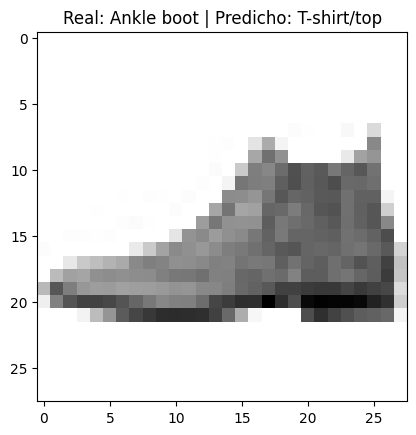

## Guía:
- **Normalización:** Si olvidas este paso, notarás que el error (loss) baja muy lentamente o el modelo no converge.
- **Activaciones:** ¿Qué sucede si usas una función lineal en lugar de ReLU en las capas ocultas? La red perdería su capacidad de detectar patrones complejos.
- **Softmax:** Observa cómo las 10 salidas de la última capa compiten entre sí; la prenda con el valor más alto es la elegida por el sistema .